In [1]:
import refinitiv.data as rd
import pandas as pd
from datetime import date, timedelta, datetime
import numpy as np
import matplotlib.pyplot as plt

In [7]:
key = '6ee58ebfc6664f1a8c09d0ba1ccbadd946078bc3'
rd.open_session(app_key=key)

<refinitiv.data.session.Definition object at 0x245ff58c0b0 {name='workspace'}>

# Initial screener

Using the screen function of refinitiv to gather all active tickers in US

In [8]:
#Using a Refinitiv SCREEN() expression to retrieve the universe of active tickers in the US
screener = (
    'SCREEN('
      'U(IN(Equity(active,public,primary))/*UNV:Public*/), '
      # US‐listed
      'TR.ExchangeCountryCode = "US"'
    ')'
)

# the data i want to gather (will be useful to do further screening)
fields = [
    'TR.CommonName',
    'TR.CompanyMarketCap(Scale=0)',
    'TR.ExchangeName',
    'TR.TRBCEconomicSector',
    'TR.TRBCIndustryGroup',
    'TR.AssetCategory',
    'TR.FirstTradeDate'
]

screener_usa = rd.get_data(screener, fields)
screener_usa

C:\Users\Ramon\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\refinitiv\data\_tools\_dataframe.py:192:FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`


,Instrument,Company Common Name,Company Market Cap,Exchange Name,TRBC Economic Sector Name,TRBC Industry Group Name,Asset Category Description,First Trade Date
0,DTRK.PK,DATATRAK International Inc,9050750.072,USA Pink Sheets,Technology,Software & IT Services,Ordinary Share,1996-06-11
1,HGYN.PK,Hong Yuan Holding Group,2761708.342,USA Pink Sheets,Industrials,Professional & Commercial Services,Ordinary Share,2005-11-04
2,FN.N,Fabrinet,17519505690.0,New York Stock Exchange,Technology,Electronic Equipment & Parts,Ordinary Share,2010-06-25
3,TGLS.N,Tecnoglass Inc,2431390775.66,New York Stock Exchange,Consumer Cyclicals,Homebuilding & Construction Supplies,Ordinary Share,2012-05-10
4,CDXS.OQ,Codexis Inc,154454694.93,Nasdaq Stock Exchange Global Select Market,Healthcare,Biotechnology & Medical Research,Ordinary Share,2010-04-22
...,...,...,...,...,...,...,...,...
13703,AKTS.OQ,Aktis Oncology Inc,1081365757.5,Nasdaq Stock Exchange Global Select Market,Healthcare,Biotechnology & Medical Research,Ordinary Share,2026-01-09
13704,TWLV.OQ,Twelve Seas Investment Company III,230859375.0,NASDAQ Stock Exchange Global Market,Financials,Investment Holding Companies,Ordinary Share,2026-01-09
13705,ATCX.OQ,Atlas Critical Minerals Corp,42628205.85,NASDAQ Stock Exchange Capital Market,Basic Materials,Metals & Mining,Ordinary Share,2026-01-09
13706,CRAN.OQ,Crane Harbor Acquisition Corp II,464310000.0,NASDAQ Stock Exchange Global Market,Financials,Investment Holding Companies,Ordinary Share,2026-01-12


# Initial filters

Avoid companies from Financials', 'Utilities', 'Real Estate', 'Government Activity', 'Institutions, Associations & Organizations' economic sectors <br>
Exclude companies that trade in OTC Markets <br>
Only companies with more than 500 million in market cap <br>
Only ordinary shares <br>
Only companies with more than 5 years of historical data

In [9]:
# Filters for the screener

# exclude financials, utilities, real estate, Government Activity and Institutions, Associations & Organizations (economic sectors)
filtered_usa = screener_usa[~screener_usa['TRBC Economic Sector Name'].isin(['Financials', 'Utilities', 'Real Estate', 'Government Activity', 
                                                                             'Institutions, Associations & Organizations'])] #keeping only those that aren't the ones in the list

# exclude companies that trade in otc markets
filtered_usa = filtered_usa[~screener_usa['Exchange Name'].isin(['USA Pink Sheets'])]

#include only companies with more than 1 billion in market cap
filtered_usa = filtered_usa[filtered_usa['Company Market Cap'] >= 5e8]

#include only ordinary shares
filtered_usa = filtered_usa[filtered_usa['Asset Category Description'] == 'Ordinary Share']

# number of years since first trade
filtered_usa['Years Since First Trade'] = (datetime.now() - filtered_usa['First Trade Date']).dt.days / 365.25

#include only companies with more than 5 years of historical data
filtered_usa = filtered_usa[filtered_usa['Years Since First Trade'] >= 5]

filtered_usa

C:\Users\Ramon\AppData\Local\Temp\ipykernel_17344\468220048.py:8:UserWarning: Boolean Series key will be reindexed to match DataFrame index.


,Instrument,Company Common Name,Company Market Cap,Exchange Name,TRBC Economic Sector Name,TRBC Industry Group Name,Asset Category Description,First Trade Date,Years Since First Trade
2,FN.N,Fabrinet,17519505690.0,New York Stock Exchange,Technology,Electronic Equipment & Parts,Ordinary Share,2010-06-25,15.556468
3,TGLS.N,Tecnoglass Inc,2431390775.66,New York Stock Exchange,Consumer Cyclicals,Homebuilding & Construction Supplies,Ordinary Share,2012-05-10,13.681040
5,NEGG.OQ,Newegg Commerce Inc,1131770590.4,NASDAQ Stock Exchange Capital Market,Technology,Software & IT Services,Ordinary Share,2010-04-22,15.731691
6,SPSC.OQ,SPS Commerce Inc,3469236648.0,Nasdaq Stock Exchange Global Select Market,Technology,Software & IT Services,Ordinary Share,2010-04-22,15.731691
10,AOSL.OQ,Alpha and Omega Semiconductor Ltd,666161732.0,Nasdaq Stock Exchange Global Select Market,Technology,Semiconductors & Semiconductor Equipment,Ordinary Share,2010-04-29,15.712526
...,...,...,...,...,...,...,...,...,...
12317,ST.N,Sensata Technologies Holding PLC,5133718621.4,New York Stock Exchange,Technology,Electronic Equipment & Parts,Ordinary Share,2010-03-11,15.846680
12330,MXL.OQ,Maxlinear Inc,1602417775.56,Nasdaq Stock Exchange Global Select Market,Technology,Semiconductors & Semiconductor Equipment,Ordinary Share,2010-03-24,15.811088
12339,STNG.N,Scorpio Tankers Inc,3110426051.1,New York Stock Exchange,Energy,Oil & Gas Related Equipment and Services,Ordinary Share,2010-03-31,15.791923
12341,SSNC.OQ,SS&C Technologies Holdings Inc,20695964048.43,Nasdaq Stock Exchange Global Select Market,Technology,Software & IT Services,Ordinary Share,2010-03-31,15.791923


In [10]:
end_date = date.today()
start_date = end_date.replace(year=end_date.year - 5)

print(start_date)
print(end_date)

2021-01-14
2026-01-14


# Functions to gather data from Refinitiv

I coded functions to gather financial data of last 5 years for building the quality factor; last price and TTM financial data for value factor; last 12 months of returns for momentum factor. <br>

All the data is retrieved initially and stored in dictionaries where the key is the ticker and the value is a DF with the data

In [11]:
fields = [
    # Income Statement
    'TR.F.TotRevenue', 'TR.F.COGSTot', 'TR.F.GrossProfIndPropTot', 'TR.F.IncBefTax', 'TR.F.IncTax', 'TR.F.NetIncAfterTax', 'TR.F.IncAvailToComShr', 
    'TR.F.EBIT', 'TR.F.EBITDA',
    # Balance Sheet
    'TR.F.CashCashEquivTot', 'TR.F.TotCurrAssets', 'TR.F.TotAssets', 'TR.F.STDebtCurrPortOfLTDebt', 'TR.F.TotCurrLiab', 'TR.F.DebtLTTot',
    'TR.F.ComEqParentShHold','TR.F.ComShrOutsTot', 'TR.F.NetDebt',
    # Cash Flow
    'TR.F.NetCashFlowOp'
]

def get_raw_data(ticker, start_date=start_date, end_date=end_date):
    df = rd.get_history(
        universe=ticker,
        fields=fields,
        parameters={'Frq': 'FY', 'Period': 'FY0'},
        start=start_date,
        end=end_date,
    )
    df = df.apply(pd.to_numeric, errors='coerce')
    return df.fillna(0)

In [12]:
fields_ttm = [
    #EV
    'TR.F.ComShrOutsTot', 'TR.F.DebtLTTot', 'TR.F.STDebtCurrPortOfLTDebt', 'TR.F.PrefShHoldEq', 'TR.F.MinIntr', 'TR.F.CashCashEquivTot',
    #CFO and FCF
    'TR.F.NetCashFlowOp', 'TR.F.LeveredFOCF',
    #EBIT, revenue and eps
    'TR.F.EBIT', 'TR.F.TotRevenue', 'TR.F.EPSBasicExclExordItemsComTot'
    ]

def get_raw_data_ttm(ticker, end_date=end_date):
    df = rd.get_history(
        universe=ticker,
        fields=fields_ttm,
        parameters={'Frq': 'FQ', 'Period': 'FQ0'},
        start= end_date - timedelta(days=365),
        end=end_date,
    )
    df = df.apply(pd.to_numeric, errors='coerce')
    return df.fillna(0)

def get_last_price(ticker, end_date=end_date):
    df = rd.get_history(
    universe = ticker,
    fields = ['TR.PriceClose'],
    interval= '1D',
    start = end_date - timedelta(days=1),
    end = end_date)

    return df.fillna(0)

def get_daily_prices_ttm(ticker, end_date=end_date):
    df = rd.get_history(
    universe = ticker,
    fields = ['TR.PriceClose'],
    interval= '1D',
    start = end_date - timedelta(days=366),
    end = end_date)

    return df.fillna(0)

In [ ]:
#store fundamental data for each ticker in a dictionary
#the keys for the dictionary are the tickers and the values the dfs with fundamental data
tickers_data = {}
error_tickers = []

for ticker in filtered_usa['Instrument']:
    try:
        tickers_data[ticker] = get_raw_data(ticker, start_date, end_date) #get raw data for each ticker
    except Exception as e:
        error_tickers.append(ticker) #if i get an error fetching data the ticker is stored so i can evaluate later
        print(f"Error fetching {ticker}: {e}")
        continue #continue with the next ticker without interruption

In [ ]:
#store fundamental data for each ticker in a dictionary
#the keys for the dictionary are the tickers and the values the dfs with fundamental data
tickers_data_ttm = {}
error_tickers_ttm = []

for ticker in filtered_usa['Instrument']:
    try:
        tickers_data_ttm[ticker] = get_raw_data_ttm(ticker, end_date) #get raw data for each ticker
    except Exception as e:
        error_tickers_ttm.append(ticker) #if i get an error fetching data the ticker is stored so i can evaluate later
        print(f"Error fetching {ticker}: {e}")
        continue #continue with the next ticker without interruption

In [ ]:
#store daily prices for each ticker in a dictionary
tickers_daily_prices = {}
error_tickers_daily_prices = []

for ticker in filtered_usa['Instrument']:
    try:
        tickers_daily_prices[ticker] = get_daily_prices_ttm(ticker, end_date)
    except Exception as e:
        error_tickers_daily_prices.append(ticker)
        print(f'Error fetching {ticker}: {e}')
        continue

In [18]:
print(error_tickers)
print(error_tickers_ttm)
print(error_tickers_daily_prices)

[]
[]
[]


In [19]:
tickers_data['UTHR.OQ']

UTHR.OQ,Revenue from Business Activities - Total,Cost of Revenues - Total,Gross Profit - Industrials/Property - Total,Income before Taxes,Income Taxes,Net Income after Tax,Income Available to Common Shares,Earnings before Interest & Taxes (EBIT),Earnings before Interest Taxes Depreciation & Amortization,Cash & Cash Equivalents - Total,Total Current Assets,Total Assets,Short-Term Debt & Current Portion of Long-Term Debt,Total Current Liabilities,Debt - Long-Term - Total,Common Equity Attributable to Parent Shareholders,Common Shares - Outstanding - Total,Net Debt,Net Cash Flow from Operating Activities
Date,,,,,,,,,,,,,,,,,,,
2020-12-31,1483300000,108100000,1375200000,638900000,124100000,514800000,514800000,593600000,643500000,738700000,2167200000,4615000000,0,323300000,800000000,3395200000,44507098,-1035000000,755700000
2021-12-31,1685500000,122500000,1563000000,593900000,118100000,475800000,475800000,688500000,738400000,894800000,2323600000,5169100000,0,305400000,800000000,3958900000,45107805,-1130700000,598200000
2022-12-31,1936300000,151600000,1784700000,950600000,223300000,727300000,727300000,990900000,1042200000,961200000,3380300000,6044500000,0,343200000,800000000,4796700000,46032064,-2038700000,802500000
2023-12-31,2327500000,257500000,2070000000,1274300000,289500000,984800000,984800000,1188500000,1241700000,1207700000,3551000000,7167000000,400000000,804400000,300000000,5984800000,47040545,-2294100000,978000000
2024-12-31,2877400000,309700000,2567700000,1539000000,343900000,1195100000,1195100000,1448100000,1520600000,1697200000,3873900000,7364000000,300000000,738100000,0,6444000000,44831306,-2967000000,1327100000


In [20]:
tickers_data_ttm['UTHR.OQ']

UTHR.OQ,Common Shares - Outstanding - Total,Debt - Long-Term - Total,Short-Term Debt & Current Portion of Long-Term Debt,Preferred Shareholders Equity,Minority Interest,Cash & Cash Equivalents - Total,Net Cash Flow from Operating Activities,Free Cash Flow,Earnings before Interest & Taxes (EBIT),Revenue from Business Activities - Total,"EPS - Basic - excl Extraordinary Items, Common - Total"
Date,,,,,,,,,,,
2024-12-31,44831306,0,300000000,0,0.0,1697200000,341200000,254500000,363700000,735900000,6.71047
2025-03-31,45074551,0,200000000,0,0.0,1899900000,461200000,386300000,382800000,794400000,7.17595
2025-06-30,45215262,0,0,0,0.0,1593100000,191700000,129500000,386200000,798600000,6.86253
2025-09-30,42902818,0,0,0,0.0,1340100000,562100000,346100000,389300000,799500000,7.73288


In [21]:
tickers_daily_prices['UTHR.OQ'].iloc[-1]

UTHR.OQ
Price Close    476.86
Name: 2026-01-13 00:00:00, dtype: Float64

In [22]:
tickers_daily_prices['AAPL.OQ']

AAPL.OQ,Price Close
Date,
2025-01-13,234.4
2025-01-14,233.28
2025-01-15,237.87
2025-01-16,228.26
2025-01-17,229.98
...,...
2026-01-07,260.33
2026-01-08,259.04
2026-01-09,259.37


# Initial quality filter

Research had show great returns when value factor is combined with Piotroski Fs-Score, in this case I'm not using it to build the quality factor but instead as an initial filter to avoid "junk". I'll only keep stocks with more than 3 of Fs-Score

In [85]:
# Initial filter to avoid junk

def fs_score(ticker): 
    df = tickers_data[ticker]
    # Require at least 2 years of fundamental data
    if len(df) < 2:
        print(f"{ticker}: not enough data for F-score")
        return None
    
    net_income, assets, lt_debt, current_assets = df['Income Available to Common Shares'], df['Total Assets'], df['Debt - Long-Term - Total'], df['Total Current Assets']
    current_liabilities, shares, revenue, gross = df['Total Current Liabilities'], df['Common Shares - Outstanding - Total'], df['Revenue from Business Activities - Total'], df['Gross Profit - Industrials/Property - Total']
    cfo = df['Net Cash Flow from Operating Activities']
    
    roa = net_income / assets
    leverage = lt_debt / assets
    current = current_assets / current_liabilities
    gross_margin = gross / revenue
    asset_turnover = revenue / assets
    
    score = 0
    try:
        # current profitability
        score += int(roa.iloc[-1] > 0) # positive roa
        score += int(roa.iloc[-1] > roa.iloc[-2]) #roa improving
        score += int(cfo.iloc[-1] > 0) #positive cfo
        score += int((cfo.iloc[-1] - net_income.iloc[-1]) > 0) # accrual quality
        # stability
        score += int(leverage.iloc[-1] < leverage.iloc[-2]) #lt debt to assets decreasing 
        score += int(current.iloc[-1] > current.iloc[-2]) #current ratio improving
        score += int(shares.iloc[-1] <= shares.iloc[-2]) #no new shares
        # operational efficiency
        score += int(gross_margin.iloc[-1] > gross_margin.iloc[-2]) #gross margin improving
        score += int(asset_turnover.iloc[-1] > asset_turnover.iloc[-2]) #asset turnover improving
        
    except Exception as e:
        print(f'F-score error: {e} with {ticker}')
        return None
    
    return score

In [86]:
# creating a df with all the tickers except the ones in error_tickers
Fscore_df = filtered_usa.loc[~filtered_usa['Instrument'].isin(error_tickers),['Instrument', 'TRBC Economic Sector Name', 'TRBC Industry Group Name']]

# applying fs_score function to each ticker
Fscore_df['FS_Score'] = Fscore_df['Instrument'].apply(fs_score)
Fscore_df = Fscore_df.dropna(subset = ['FS_Score'])

# Sorting them by fscore
Fscore_df = Fscore_df.sort_values(by = 'FS_Score', ascending = False)
Fscore_df

,Instrument,TRBC Economic Sector Name,TRBC Industry Group Name,FS_Score
9495,BKR.OQ,Energy,Oil & Gas Related Equipment and Services,9
538,BFAM.N,Consumer Non-Cyclicals,Personal & Household Products & Services,9
6910,ICFI.OQ,Industrials,Professional & Commercial Services,9
9554,CCK.N,Basic Materials,Containers & Packaging,9
5919,FOXA.OQ,Consumer Cyclicals,Media & Publishing,9
...,...,...,...,...
5851,IDYA.OQ,Healthcare,Biotechnology & Medical Research,1
6852,AIOT.OQ,Technology,Software & IT Services,1
6631,AEHR.OQ,Technology,Semiconductors & Semiconductor Equipment,0
6149,COGT.OQ,Healthcare,Biotechnology & Medical Research,0


C:\Users\Ramon\AppData\Local\Temp\ipykernel_17344\860687396.py:13:UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


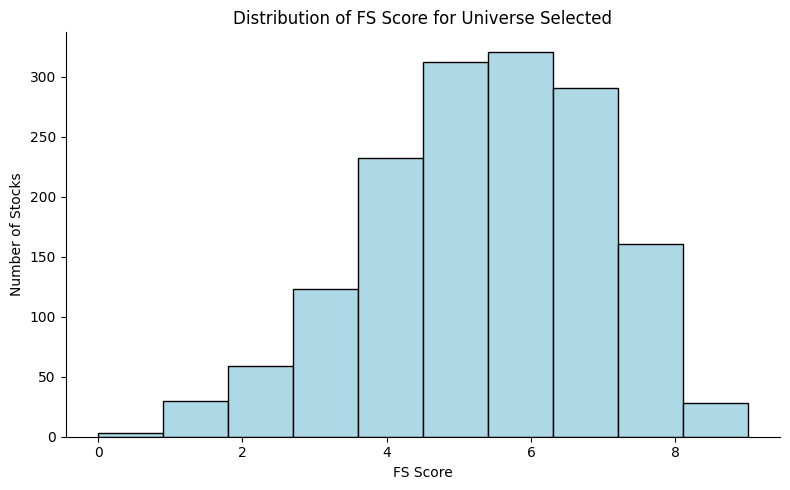

In [87]:
# Distribution of Fs_score for the universe selected

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(Fscore_df['FS_Score'], bins=10, color='lightblue', edgecolor='black')
ax.set_title('Distribution of FS Score for Universe Selected')
ax.set_ylabel('Number of Stocks')
ax.set_xlabel('FS Score')

ax.spines[['top', 'right']].set_visible(False)

fig.tight_layout()
fig.show()

In [88]:
# Avoid junk stocks
# Keep only stocks with fscore above 3

final_stocks = Fscore_df.loc[Fscore_df['FS_Score'] > 3]
final_stocks

,Instrument,TRBC Economic Sector Name,TRBC Industry Group Name,FS_Score
9495,BKR.OQ,Energy,Oil & Gas Related Equipment and Services,9
538,BFAM.N,Consumer Non-Cyclicals,Personal & Household Products & Services,9
6910,ICFI.OQ,Industrials,Professional & Commercial Services,9
9554,CCK.N,Basic Materials,Containers & Packaging,9
5919,FOXA.OQ,Consumer Cyclicals,Media & Publishing,9
...,...,...,...,...
6956,NEOG.OQ,Healthcare,Healthcare Equipment & Supplies,4
11767,LXU.N,Basic Materials,Chemicals,4
6,SPSC.OQ,Technology,Software & IT Services,4
43,TSLA.OQ,Consumer Cyclicals,Automobiles & Auto Parts,4


In [89]:
final_stocks['TRBC Economic Sector Name'].value_counts()

TRBC Economic Sector Name
Technology                         311
Industrials                        277
Consumer Cyclicals                 257
Healthcare                         214
Basic Materials                     97
Consumer Non-Cyclicals              92
Energy                              86
Academic & Educational Services     11
Name: count, dtype: Int64

# Quality factor

In [90]:
#profitability
def roa(ticker):
    try:
        df = tickers_data[ticker]
        ni, assets = df['Income Available to Common Shares'], df['Total Assets']
        roa = ni / assets
        return roa.mean(), roa.std()
    
    except Exception as e:
        print(f'Error with {ticker}: {e}')
        return None

def roic(ticker, tax_cap=.35):
    try:
        df = tickers_data[ticker]  
        ebit, ebt, i_taxes = df['Earnings before Interest & Taxes (EBIT)'], df['Income before Taxes'], df['Income Taxes']
        st_debt, lt_debt = df['Short-Term Debt & Current Portion of Long-Term Debt'], df['Debt - Long-Term - Total']
        equity, cash = df["Common Equity Attributable to Parent Shareholders"], df['Cash & Cash Equivalents - Total']
        
        eff_tax_rate = (i_taxes / ebt).clip(0, tax_cap) # in case is negative or really high
        total_debt = st_debt + lt_debt
        nopat = ebit * (1 - eff_tax_rate)
        i_capital = equity + total_debt - cash
        roic = nopat / i_capital
        return roic.mean(), roic.std()
    
    except Exception as e:
        print(f'Error with {ticker}: {e}')
        return None
    
def gp_assets(ticker):
    try:
        df = tickers_data[ticker]
        gross, assets = df['Gross Profit - Industrials/Property - Total'], df['Total Assets']
        gp_assets = gross / assets
        return gp_assets.mean(), gp_assets.std()

    except Exception as e:
        print(f'Error with {ticker}: {e}')
        return None
    
# earnings quality (accruals)

def acc_assets(ticker):
    try:
        df = tickers_data[ticker]
        cfo, ni, assets = df['Net Cash Flow from Operating Activities'], df['Income Available to Common Shares'], df['Total Assets']
        acc = ni - cfo
        last_acc = acc.iloc[-1]
        if assets.iloc[-1] == 0 or assets.iloc[-2] == 0:
            return np.nan #return na if assets are 0 to avoid inf
        last_avg_assets = (assets[-1] + assets[-2]) / 2
        acc_a = last_acc / last_avg_assets
        return acc_a
      
    except Exception as e:
        print(f'Error with {ticker}: {e}')
        return None


# leverage

def ndebt_ebitda(ticker):
    #if one negative ebitda i will override the ndebt_ebitda z score with the 20th percentile
    #if two negative ebitda i will override the ndebt_ebitda z score with the 5th percentile
    #if three negative i will just invalidate and drop stock
    try:
        df = tickers_data[ticker]
        n_debt, ebitda = df['Net Debt'], df['Earnings before Interest Taxes Depreciation & Amortization']
        neg_count = (ebitda.tail(3) <= 0).sum()
        if neg_count == 1:
            return None, 'P'
        elif neg_count == 2:
            return None, 'HP'
        elif neg_count == 3:
            return None, 'INV'
        
        nd_clip = n_debt.tail(3).clip(lower=0) #make negative net debt into 0
        nd_ebitda = nd_clip / ebitda.tail(3)
        return nd_ebitda.tail(3).median(), 'VAL'

    except Exception as e:
        print(f'Error with {ticker}: {e}')
        return None

def debt_assets(ticker):
    try:
        df = tickers_data[ticker]
        st_debt, lt_debt, assets = df['Short-Term Debt & Current Portion of Long-Term Debt'], df['Debt - Long-Term - Total'], df['Total Assets']
        tot_debt = st_debt + lt_debt
        d_a = tot_debt / assets
        return d_a.tail(3).median()

    except Exception as e:
        print(f'Error with {ticker}: {e}')
        return None

In [91]:
print(roa('META.OQ'))
print(roic('META.OQ'))
print(gp_assets('META.OQ'))
print(acc_assets('META.OQ'))
print(ndebt_ebitda('META.OQ'))
print(debt_assets('META.OQ'))


(np.float64(0.18824291882528965), np.float64(0.04520787866833331))
(np.float64(0.306659577433299), np.float64(0.06286436496761039))
(np.float64(0.49395691953051724), np.float64(0.050952517772568325))
-0.11457115906003239
(np.float64(0.0), 'VAL')
0.08307094672571999


C:\Users\Ramon\AppData\Local\Temp\ipykernel_17344\1871974361.py:52:FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`


In [92]:
# creating a df with all the tickers except the ones in error_tickers
quality_metrics_df = final_stocks[['Instrument', 'TRBC Economic Sector Name']].copy()

# applying fs_score function to each ticker
quality_metrics_df[['roa', 'roa_std']] = quality_metrics_df['Instrument'].apply(roa).apply(pd.Series)
quality_metrics_df[['roic', 'roic_std']] = quality_metrics_df['Instrument'].apply(roic).apply(pd.Series)
quality_metrics_df[['gp_assets', 'gp_assets_std']] = quality_metrics_df['Instrument'].apply(gp_assets).apply(pd.Series)
quality_metrics_df['acc_assets'] = quality_metrics_df['Instrument'].apply(acc_assets)
quality_metrics_df[['ndebt_ebitda', 'valid']]  = quality_metrics_df['Instrument'].apply(ndebt_ebitda).apply(pd.Series) #fun return 2 values, df will have 2 columns
quality_metrics_df['debt_assets'] = quality_metrics_df['Instrument'].apply(debt_assets)
quality_metrics_df

C:\Users\Ramon\AppData\Local\Temp\ipykernel_17344\1871974361.py:52:FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`


,Instrument,TRBC Economic Sector Name,roa,roa_std,roic,roic_std,gp_assets,gp_assets_std,acc_assets,ndebt_ebitda,valid,debt_assets
9495,BKR.OQ,Energy,-0.031014,0.134845,0.087362,0.047891,0.126432,0.024869,-0.009375,0.619883,VAL,0.162945
538,BFAM.N,Consumer Non-Cyclicals,0.020608,0.010414,0.055003,0.019432,0.116289,0.030158,-0.050932,3.083090,VAL,0.247107
6910,ICFI.OQ,Industrials,0.039302,0.008864,0.072778,0.015326,0.305164,0.018771,-0.030099,2.281397,VAL,0.222094
9554,CCK.N,Basic Materials,0.021133,0.035429,0.122182,0.02538,0.129057,0.020188,-0.053182,3.278427,VAL,0.488357
5919,FOXA.OQ,Consumer Cyclicals,0.074128,0.020413,0.153215,0.018946,0.211937,0.014062,-0.046981,0.925354,VAL,0.327553
...,...,...,...,...,...,...,...,...,...,...,...,...
6956,NEOG.OQ,Healthcare,-0.041876,0.15697,0.034311,0.032319,0.158385,0.074844,-0.287836,3.771075,VAL,0.195839
11767,LXU.N,Basic Materials,-0.02468,0.132195,0.071769,0.098309,0.097505,0.089935,-0.085242,2.353030,VAL,0.458424
6,SPSC.OQ,Technology,0.079112,0.005671,0.143548,0.021727,0.403315,0.014451,-0.086621,0.000000,VAL,0.000000
43,TSLA.OQ,Consumer Cyclicals,0.09081,0.057888,0.213877,0.132975,0.181595,0.053028,-0.068154,0.000000,VAL,0.049054


In [93]:
quality_metrics_df.isna().sum()

Instrument                     0
TRBC Economic Sector Name      0
roa                            7
roa_std                       13
roic                           7
roic_std                      12
gp_assets                      7
gp_assets_std                 13
acc_assets                     0
ndebt_ebitda                 198
valid                          0
debt_assets                    0
dtype: int64

In [94]:
# drop the companies with 3 last years of consecutive negative ebitda
quality_metrics_df = quality_metrics_df[quality_metrics_df['valid'] != 'INV']
quality_metrics_df

,Instrument,TRBC Economic Sector Name,roa,roa_std,roic,roic_std,gp_assets,gp_assets_std,acc_assets,ndebt_ebitda,valid,debt_assets
9495,BKR.OQ,Energy,-0.031014,0.134845,0.087362,0.047891,0.126432,0.024869,-0.009375,0.619883,VAL,0.162945
538,BFAM.N,Consumer Non-Cyclicals,0.020608,0.010414,0.055003,0.019432,0.116289,0.030158,-0.050932,3.083090,VAL,0.247107
6910,ICFI.OQ,Industrials,0.039302,0.008864,0.072778,0.015326,0.305164,0.018771,-0.030099,2.281397,VAL,0.222094
9554,CCK.N,Basic Materials,0.021133,0.035429,0.122182,0.02538,0.129057,0.020188,-0.053182,3.278427,VAL,0.488357
5919,FOXA.OQ,Consumer Cyclicals,0.074128,0.020413,0.153215,0.018946,0.211937,0.014062,-0.046981,0.925354,VAL,0.327553
...,...,...,...,...,...,...,...,...,...,...,...,...
6956,NEOG.OQ,Healthcare,-0.041876,0.15697,0.034311,0.032319,0.158385,0.074844,-0.287836,3.771075,VAL,0.195839
11767,LXU.N,Basic Materials,-0.02468,0.132195,0.071769,0.098309,0.097505,0.089935,-0.085242,2.353030,VAL,0.458424
6,SPSC.OQ,Technology,0.079112,0.005671,0.143548,0.021727,0.403315,0.014451,-0.086621,0.000000,VAL,0.000000
43,TSLA.OQ,Consumer Cyclicals,0.09081,0.057888,0.213877,0.132975,0.181595,0.053028,-0.068154,0.000000,VAL,0.049054


In [95]:
#drop na values except in ndebt_ebitda
quality_metrics_df = quality_metrics_df.dropna(subset=['roa', 'roa_std', 'gp_assets', 'gp_assets_std', 'roic', 'roic_std', 'acc_assets'])

In [96]:
quality_metrics_df.isna().sum()

Instrument                     0
TRBC Economic Sector Name      0
roa                            0
roa_std                        0
roic                           0
roic_std                       0
gp_assets                      0
gp_assets_std                  0
acc_assets                     0
ndebt_ebitda                 110
valid                          0
debt_assets                    0
dtype: int64

In [97]:
#NO SECTOR NEUTRALIZE AND PERCENTILES
quality_score_df = quality_metrics_df.copy()

#winsorize

lower_bound = .01
upper_bound = .99

roa_clip = quality_score_df['roa'].clip(lower=quality_score_df['roa'].quantile(lower_bound),
                                     upper=quality_score_df['roa'].quantile(upper_bound))

roa_std_clip = quality_score_df['roa_std'].clip(lower=quality_score_df['roa_std'].quantile(lower_bound),
                                            upper=quality_score_df['roa_std'].quantile(upper_bound))

roic_clip = quality_score_df['roic'].clip(lower=quality_score_df['roic'].quantile(lower_bound),
                                        upper=quality_score_df['roic'].quantile(upper_bound))
    
roic_std_clip = quality_score_df['roic_std'].clip(lower=quality_score_df['roic_std'].quantile(lower_bound),
                                                upper=quality_score_df['roic_std'].quantile(upper_bound))
    
gp_assets_clip = quality_score_df['gp_assets'].clip(lower=quality_score_df['gp_assets'].quantile(lower_bound),
                                                                   upper=quality_score_df['gp_assets'].quantile(upper_bound))

gp_assets_std_clip = quality_score_df['gp_assets_std'].clip(lower=quality_score_df['gp_assets_std'].quantile(lower_bound),
                                                                           upper=quality_score_df['gp_assets_std'].quantile(upper_bound))
    
acc_clip = quality_score_df['acc_assets'].clip(lower=quality_score_df['acc_assets'].quantile(lower_bound),
                                                              upper=quality_score_df['acc_assets'].quantile(upper_bound))
    
ndebt_ebitda_clip = quality_score_df['ndebt_ebitda'].clip(lower=quality_score_df['ndebt_ebitda'].quantile(lower_bound),
                                                                         upper=quality_score_df['ndebt_ebitda'].quantile(upper_bound))
    
debt_assets_clip = quality_score_df['debt_assets'].clip(lower=quality_score_df['debt_assets'].quantile(lower_bound),
                                                                       upper=quality_score_df['debt_assets'].quantile(upper_bound))

#for net debt to ebitda, transform the P, HP into 80th and 95th percentile
#higher net debt to ebitda is worse, so to penalize ill add the score of the 80th and 95th percentile
q80 = ndebt_ebitda_clip.quantile(.8)
q95 = ndebt_ebitda_clip.quantile(.95)

mask_p = quality_score_df['valid'] == 'P'
mask_hp = quality_score_df['valid'] == 'HP'
ndebt_ebitda_clip = ndebt_ebitda_clip.copy()
ndebt_ebitda_clip.loc[mask_p] = q80
ndebt_ebitda_clip.loc[mask_hp] = q95

# calculating percentiles
quality_score_df['roa_p'] = roa_clip.rank(pct=True) * 100
quality_score_df['roa_std_p'] = roa_std_clip.rank(pct=True) * 100
quality_score_df['roic_p'] = roic_clip.rank(pct=True) * 100
quality_score_df['roic_std_p'] = roic_std_clip.rank(pct=True) * 100
quality_score_df['gp_assets_p'] = gp_assets_clip.rank(pct=True) * 100
quality_score_df['gp_assets_std_p'] = gp_assets_std_clip.rank(pct=True) * 100
quality_score_df['acc_assets_p'] = acc_clip.rank(pct=True) * 100
quality_score_df['ndebt_ebitda_p'] = ndebt_ebitda_clip.rank(pct=True) * 100
quality_score_df['debt_assets_p'] = debt_assets_clip.rank(pct=True) * 100

# Final quality score
lam = .2 # how much do i want to penalize volatility
quality_score_df['profitability_score'] = (.2 * (quality_score_df['roa_p'] - lam * quality_score_df['roa_std_p']) +
                                        .2 * (quality_score_df['roic_p'] - lam * quality_score_df['roic_std_p']) + 
                                        .4 * (quality_score_df['gp_assets_p'] - lam * quality_score_df['gp_assets_std_p']))
quality_score_df['accrual_score'] = -(quality_score_df['acc_assets_p']) # negative because higher accruals are worse
quality_score_df['leverage_score'] = -(.75 * quality_score_df['ndebt_ebitda_p'] + 
                                    .25 * quality_score_df['debt_assets_p']) #negative because higher leverage is worse
quality_score_df['quality_score'] = (.5 * quality_score_df['profitability_score'] + 
                                  .3 * quality_score_df['accrual_score'] + 
                                  .20 * quality_score_df['leverage_score'])

# Creating a rank column and sorting them by rank
quality_score_df['quality_p'] = quality_score_df['quality_score'].rank(pct=True) * 100
quality_score_df['quality_rank'] = quality_score_df['quality_score'].rank(ascending = False)
quality_score_df = quality_score_df.sort_values(by = 'quality_score', ascending = False)

quality_score_df.head(20)

,Instrument,TRBC Economic Sector Name,roa,roa_std,roic,roic_std,gp_assets,gp_assets_std,acc_assets,ndebt_ebitda,...,gp_assets_std_p,acc_assets_p,ndebt_ebitda_p,debt_assets_p,profitability_score,accrual_score,leverage_score,quality_score,quality_p,quality_rank
5342,SGHC.N,Consumer Cyclicals,0.169614,0.120939,0.530057,0.313248,1.55212,0.102348,-0.178620,0.000000,...,86.367281,4.811548,11.467522,14.835605,63.563753,-4.811548,-12.309543,27.876504,100.000000,1.0
6850,MANH.OQ,Technology,0.233756,0.041312,24.071044,40.190121,0.701283,0.038726,-0.107120,0.000000,...,47.233360,14.113873,11.467522,3.728949,67.621492,-14.113873,-9.532879,27.670008,99.919808,2.0
6273,CARG.OQ,Technology,0.084507,0.09167,0.347455,0.182158,0.793684,0.145009,-0.269030,0.000000,...,93.584603,1.363272,11.467522,3.728949,57.735365,-1.363272,-9.532879,26.552125,99.839615,3.0
7189,LQDT.OQ,Technology,0.108887,0.059685,0.651723,0.300712,0.533074,0.025261,-0.107107,0.000000,...,28.147554,14.194066,11.467522,3.728949,62.729751,-14.194066,-9.532879,25.200080,99.759423,4.0
6730,CPRX.OQ,Healthcare,0.224284,0.096247,8.600676,17.487955,0.525877,0.084003,-0.114896,0.000000,...,79.069767,12.028869,11.467522,3.728949,61.071371,-12.028869,-9.532879,25.020449,99.679230,5.0
371,META.OQ,Technology,0.188243,0.045208,0.30666,0.062864,0.493957,0.050953,-0.114571,0.000000,...,60.946271,12.109062,11.467522,20.609463,61.831596,-12.109062,-13.753007,24.532478,99.599038,6.0
6930,ODFL.OQ,Industrials,0.21879,0.046368,0.30372,0.059047,0.901623,0.103732,-0.086009,0.000000,...,86.607859,20.850040,11.467522,13.472334,64.891740,-20.850040,-11.968725,23.797113,99.518845,7.0
977,ATEN.N,Technology,0.129625,0.067259,0.355209,0.104099,0.543417,0.057117,-0.098106,0.000000,...,65.276664,16.359262,11.467522,3.728949,60.458701,-16.359262,-9.532879,23.414996,99.438653,8.0
6633,ADBE.OQ,Technology,0.192004,0.028034,0.433001,0.106883,0.595154,0.079461,-0.097144,0.000000,...,77.866881,16.680032,11.467522,35.525261,63.666399,-16.680032,-17.481957,23.332799,99.358460,9.0
9877,IDT.N,Technology,0.112103,0.050779,0.807425,0.211935,0.651336,0.072868,-0.086657,0.000000,...,75.461107,20.288693,11.467522,3.728949,61.927827,-20.288693,-9.532879,22.970730,99.278268,10.0


In [98]:
# To sector neutralize the ratios i have to groupby each sector
sectors = list(quality_metrics_df['TRBC Economic Sector Name'].unique())

sector_quality_z_df = {}

# for each sector i create a new key (as the sector) and a df (as the value) inside the dictionary with all the rows that are the same sector
for sector in sectors:
    sector_quality_z_df[sector] = quality_metrics_df[quality_metrics_df['TRBC Economic Sector Name'] == sector]

print(sectors)

['Energy', 'Consumer Non-Cyclicals', 'Industrials', 'Basic Materials', 'Consumer Cyclicals', 'Technology', 'Healthcare', 'Academic & Educational Services']


In [99]:
# Sector neutralize each metric
# Winsorize and then calculate z scores for each sector

for sector in sectors:
    # winsorize
    lower_bound = .01
    upper_bound = .99

    roa_clip = sector_quality_z_df[sector]['roa'].clip(lower=sector_quality_z_df[sector]['roa'].quantile(lower_bound),
                                                       upper=sector_quality_z_df[sector]['roa'].quantile(upper_bound))
    
    roa_std_clip = sector_quality_z_df[sector]['roa_std'].clip(lower=sector_quality_z_df[sector]['roa_std'].quantile(lower_bound),
                                                               upper=sector_quality_z_df[sector]['roa_std'].quantile(upper_bound))
    
    roic_clip = sector_quality_z_df[sector]['roic'].clip(lower=sector_quality_z_df[sector]['roic'].quantile(lower_bound),
                                                         upper=sector_quality_z_df[sector]['roic'].quantile(upper_bound))
    
    roic_std_clip = sector_quality_z_df[sector]['roic_std'].clip(lower=sector_quality_z_df[sector]['roic_std'].quantile(lower_bound),
                                                                 upper=sector_quality_z_df[sector]['roic_std'].quantile(upper_bound))
    
    gp_assets_clip = sector_quality_z_df[sector]['gp_assets'].clip(lower=sector_quality_z_df[sector]['gp_assets'].quantile(lower_bound),
                                                                   upper=sector_quality_z_df[sector]['gp_assets'].quantile(upper_bound))
    
    gp_assets_std_clip = sector_quality_z_df[sector]['gp_assets_std'].clip(lower=sector_quality_z_df[sector]['gp_assets_std'].quantile(lower_bound),
                                                                           upper=sector_quality_z_df[sector]['gp_assets_std'].quantile(upper_bound))
    
    acc_clip = sector_quality_z_df[sector]['acc_assets'].clip(lower=sector_quality_z_df[sector]['acc_assets'].quantile(lower_bound),
                                                              upper=sector_quality_z_df[sector]['acc_assets'].quantile(upper_bound))
    
    ndebt_ebitda_clip = sector_quality_z_df[sector]['ndebt_ebitda'].clip(lower=sector_quality_z_df[sector]['ndebt_ebitda'].quantile(lower_bound),
                                                                         upper=sector_quality_z_df[sector]['ndebt_ebitda'].quantile(upper_bound))
    
    debt_assets_clip = sector_quality_z_df[sector]['debt_assets'].clip(lower=sector_quality_z_df[sector]['debt_assets'].quantile(lower_bound),
                                                                       upper=sector_quality_z_df[sector]['debt_assets'].quantile(upper_bound))
    
    #for net debt to ebitda, transform the P, HP into 80th and 95th percentile
    #higher net debt to ebitda is worse, so to penalize ill add the score of the 80th and 95th percentile
    q80 = ndebt_ebitda_clip.quantile(.8)
    q95 = ndebt_ebitda_clip.quantile(.95)

    mask_p = sector_quality_z_df[sector]['valid'] == 'P'
    mask_hp = sector_quality_z_df[sector]['valid'] == 'HP'
    ndebt_ebitda_clip = ndebt_ebitda_clip.copy()
    ndebt_ebitda_clip.loc[mask_p] = q80
    ndebt_ebitda_clip.loc[mask_hp] = q95

    # calculating z score
    # how strong is this stock on this metric relative to its peers?
    sector_quality_z_df[sector]['roa_z'] = (roa_clip - roa_clip.mean()) / roa_clip.std()
    sector_quality_z_df[sector]['roa_std_z'] = (roa_std_clip - roa_std_clip.mean()) / roa_std_clip.std()
    sector_quality_z_df[sector]['roic_z'] = (roic_clip - roic_clip.mean()) / roic_clip.std()
    sector_quality_z_df[sector]['roic_std_z'] = (roic_std_clip - roic_std_clip.mean()) / roic_std_clip.std()
    sector_quality_z_df[sector]['gp_assets_z'] = (gp_assets_clip - gp_assets_clip.mean()) / gp_assets_clip.std()
    sector_quality_z_df[sector]['gp_assets_std_z'] = (gp_assets_std_clip - gp_assets_std_clip.mean()) / gp_assets_std_clip.std()
    sector_quality_z_df[sector]['acc_assets_z'] = (acc_clip - acc_clip.mean()) / acc_clip.std()
    sector_quality_z_df[sector]['ndebt_ebitda_z'] = (ndebt_ebitda_clip - ndebt_ebitda_clip.mean()) / ndebt_ebitda_clip.std()
    sector_quality_z_df[sector]['debt_assets_z'] = (debt_assets_clip - debt_assets_clip.mean()) / debt_assets_clip.std()

    # Final quality score
    lam = .2 # how much do i want to penalize volatility
    sector_quality_z_df[sector]['profitability_score'] = (.2 * (sector_quality_z_df[sector]['roa_z'] - lam * sector_quality_z_df[sector]['roa_std_z']) +
                                                          .2 * (sector_quality_z_df[sector]['roic_z'] - lam * sector_quality_z_df[sector]['roic_std_z']) + 
                                                          .4 * (sector_quality_z_df[sector]['gp_assets_z'] - lam * sector_quality_z_df[sector]['gp_assets_std_z']))
    sector_quality_z_df[sector]['accrual_score'] = -(sector_quality_z_df[sector]['acc_assets_z']) # negative because higher accruals are worse
    sector_quality_z_df[sector]['leverage_score'] = -(.75 * sector_quality_z_df[sector]['ndebt_ebitda_z'] + 
                                                      .25 * sector_quality_z_df[sector]['debt_assets_z']) #negative because higher leverage is worse
    sector_quality_z_df[sector]['quality_score'] = (.5 * sector_quality_z_df[sector]['profitability_score'] + 
                                                    .3 * sector_quality_z_df[sector]['accrual_score'] + 
                                                    .2 * sector_quality_z_df[sector]['leverage_score'])
    
# Concatenate all the dfs and rank all stocks with quality score
quality_score_sector_z_df = pd.concat(sector_quality_z_df.values(), ignore_index=True) # concatenate all the values inside the dictionary (the dfs)

# Creating a rank column and sorting them by rank
quality_score_sector_z_df['quality_p'] = quality_score_sector_z_df['quality_score'].rank(pct=True) * 100
quality_score_sector_z_df['quality_rank'] = quality_score_sector_z_df['quality_score'].rank(ascending = False)
quality_score_sector_z_df = quality_score_sector_z_df.sort_values(by = 'quality_score', ascending = False)
quality_score_sector_z_df.head(20)

C:\Users\Ramon\AppData\Local\Temp\ipykernel_17344\4126660311.py:49:SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
C:\Users\Ramon\AppData\Local\Temp\ipykernel_17344\4126660311.py:50:SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
C:\Users\Ramon\AppData\Local\Temp\ipykernel_17344\4126660311.py:51:SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-doc

,Instrument,TRBC Economic Sector Name,roa,roa_std,roic,roic_std,gp_assets,gp_assets_std,acc_assets,ndebt_ebitda,...,gp_assets_std_z,acc_assets_z,ndebt_ebitda_z,debt_assets_z,profitability_score,accrual_score,leverage_score,quality_score,quality_p,quality_rank
740,SGHC.N,Consumer Cyclicals,0.169614,0.120939,0.530057,0.313248,1.55212,0.102348,-0.178620,0.000000,...,0.558971,-2.353829,-0.946662,-1.052314,1.704927,2.353829,0.973075,1.753227,100.000000,1.0
290,ODFL.OQ,Industrials,0.21879,0.046368,0.30372,0.059047,0.901623,0.103732,-0.086009,0.000000,...,1.560224,-0.869298,-1.020573,-1.496140,2.074669,0.869298,1.139465,1.526017,99.919808,2.0
877,CARG.OQ,Technology,0.084507,0.09167,0.347455,0.182158,0.793684,0.145009,-0.269030,0.000000,...,2.347546,-2.382975,-0.948221,-1.100205,1.171544,2.382975,0.986217,1.497908,99.839615,3.0
454,LPX.N,Basic Materials,0.313098,0.227269,0.525856,0.376654,0.499744,0.26551,-0.073911,0.012030,...,3.784802,-0.425186,-1.394490,-0.963319,2.167276,0.425186,1.286697,1.468533,99.759423,4.0
367,KFRC.N,Industrials,0.154048,0.028795,0.352857,0.063418,1.044276,0.187948,-0.101870,0.427680,...,3.784762,-1.180546,-0.775859,-1.036447,1.888342,1.180546,0.841006,1.466536,99.679230,5.0
1061,CLBT.OQ,Technology,-0.018491,0.281034,-0.112881,0.339989,0.515247,0.062742,-0.678699,0.000000,...,0.305441,-3.775388,-0.948221,-1.100205,0.157916,3.775388,0.986217,1.408818,99.599038,6.0
413,RHI.N,Industrials,0.153831,0.056582,0.495361,0.245507,0.876642,0.106876,-0.054174,0.000000,...,1.643258,-0.244621,-1.020573,-1.554497,2.055151,0.244621,1.154054,1.331772,99.518845,7.0
507,AMR.N,Basic Materials,0.178567,0.325508,0.483895,0.534706,0.301463,0.283057,-0.161965,0.000000,...,4.097425,-2.008015,-1.402153,-1.874675,0.836477,2.008015,1.520284,1.3247,99.438653,8.0
114,SAM.N,Consumer Non-Cyclicals,0.059458,0.047294,0.131171,0.066857,0.617931,0.05544,-0.141191,0.000000,...,0.355035,-2.551981,-1.435680,-1.602124,0.421061,2.551981,1.477291,1.271583,99.358460,9.0
171,NUS.N,Consumer Non-Cyclicals,0.027504,0.079116,0.133462,0.085381,0.894904,0.126578,-0.157744,1.638848,...,2.351738,-2.982384,-0.289754,-0.182472,0.613319,2.982384,0.262933,1.253961,99.278268,10.0


In [100]:
quality_score_sector_z_df.isna().sum()

Instrument                     0
TRBC Economic Sector Name      0
roa                            0
roa_std                        0
roic                           0
roic_std                       0
gp_assets                      0
gp_assets_std                  0
acc_assets                     0
ndebt_ebitda                 110
valid                          0
debt_assets                    0
roa_z                          0
roa_std_z                      0
roic_z                         0
roic_std_z                     0
gp_assets_z                    0
gp_assets_std_z                0
acc_assets_z                   0
ndebt_ebitda_z                 0
debt_assets_z                  0
profitability_score            0
accrual_score                  0
leverage_score                 0
quality_score                  0
quality_p                      0
quality_rank                   0
dtype: int64

# Value Factor

In [101]:
def enterprise_value(ticker):
    try:
        df = tickers_data_ttm[ticker]
        last_price = float(tickers_daily_prices[ticker].iloc[-1])
        st_debt, lt_debt, shares = df['Short-Term Debt & Current Portion of Long-Term Debt'], df['Debt - Long-Term - Total'], df['Common Shares - Outstanding - Total']
        prefered, minority, cash = df['Preferred Shareholders Equity'], df['Minority Interest'], df['Cash & Cash Equivalents - Total']

        market_cap = shares.iloc[-1] * last_price
        total_debt = st_debt.sum() + lt_debt.sum()
        ev = market_cap + total_debt + prefered.iloc[-1] + minority.iloc[-1] - cash.iloc[-1]
        return ev
    
    except Exception as e:
        print(f'Error with {ticker}: {e}')
        return None
    
def ebit_ev(ticker):
    try:
        df = tickers_data_ttm[ticker]
        ev = enterprise_value(ticker)
        ebit = df['Earnings before Interest & Taxes (EBIT)']
        if ev < 0:
            return None
        ebit_ev = ebit.sum() / ev
        return ebit_ev
    
    except Exception as e:
        print(f'Error with {ticker}: {e}')
        return None
    
def fcf_ev(ticker):
    try:
        df = tickers_data_ttm[ticker]
        ev = enterprise_value(ticker)
        fcf = df['Free Cash Flow']
        if ev < 0:
            return None
        fcf_ev = fcf.sum() / ev
        return fcf_ev
    
    except Exception as e:
        print(f'Error with {ticker}: {e}')
        return None

def sales_p(ticker):
    try:
        df = tickers_data_ttm[ticker]
        last_price = float(tickers_daily_prices[ticker].iloc[-1])
        sales, shares = df['Revenue from Business Activities - Total'], df['Common Shares - Outstanding - Total']
        #for some reason if the company fillings are recent some values (like shares outstanding) are 0 (probably a problem with the api)
        if shares.iloc[-1] == 0:
            sps = sales.sum() / float(shares.iloc[-2])
        else:
            sps = sales.sum() / float(shares.iloc[-1])
        sales_p = sps / last_price
        return sales_p
    
    except Exception as e:
        print(f'Error with {ticker}: {e}')
        return None
    
def earnings_yield(ticker):
    try:
        df = tickers_data_ttm[ticker]
        last_price = float(tickers_daily_prices[ticker].iloc[-1])
        eps = df['EPS - Basic - excl Extraordinary Items, Common - Total']
        e_yield = eps.sum() / last_price
        return e_yield
    
    except Exception as e:
        print(f'Error with {ticker}: {e}')
        return None

In [102]:
print(enterprise_value('GOOGL.OQ'))
print(ebit_ev('GOOGL.OQ'))
print(fcf_ev('GOOGL.OQ'))
print(sales_p('GOOGL.OQ'))
print(earnings_yield('GOOGL.OQ'))

4114605690000.0005
0.03168031394036205
0.017875831985251542
0.09500334674493408
0.030434919784504567


C:\Users\Ramon\AppData\Local\Temp\ipykernel_17344\659702760.py:4:FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
C:\Users\Ramon\AppData\Local\Temp\ipykernel_17344\659702760.py:48:FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
C:\Users\Ramon\AppData\Local\Temp\ipykernel_17344\659702760.py:65:FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead


In [103]:
value_metrics = final_stocks[['Instrument', 'TRBC Economic Sector Name']].copy()
value_metrics['ebit_ev'] = value_metrics['Instrument'].apply(ebit_ev)
value_metrics['fcf_ev'] = value_metrics['Instrument'].apply(fcf_ev)
value_metrics['sales_p'] = value_metrics['Instrument'].apply(sales_p)
value_metrics['earnings_yield'] = value_metrics['Instrument'].apply(earnings_yield)
value_metrics

C:\Users\Ramon\AppData\Local\Temp\ipykernel_17344\659702760.py:4:FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
C:\Users\Ramon\AppData\Local\Temp\ipykernel_17344\659702760.py:24:RuntimeWarning: invalid value encountered in scalar divide
C:\Users\Ramon\AppData\Local\Temp\ipykernel_17344\659702760.py:24:RuntimeWarning: divide by zero encountered in scalar divide
C:\Users\Ramon\AppData\Local\Temp\ipykernel_17344\659702760.py:4:FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
C:\Users\Ramon\AppData\Local\Temp\ipykernel_17344\659702760.py:38:RuntimeWarning: invalid value encountered in scalar divide
C:\Users\Ramon\AppData\Local\Temp\ipykernel_17344\659702760.py:38:RuntimeWarning: divide by zero encountered in scalar divide


Error with CYD.N: single positional indexer is out-of-bounds
Error with CYD.N: '<' not supported between instances of 'NoneType' and 'int'
Error with FLNG.N: single positional indexer is out-of-bounds
Error with FLNG.N: '<' not supported between instances of 'NoneType' and 'int'
Error with BGM.OQ: single positional indexer is out-of-bounds
Error with BGM.OQ: '<' not supported between instances of 'NoneType' and 'int'
Error with CYD.N: single positional indexer is out-of-bounds
Error with CYD.N: '<' not supported between instances of 'NoneType' and 'int'
Error with FLNG.N: single positional indexer is out-of-bounds
Error with FLNG.N: '<' not supported between instances of 'NoneType' and 'int'
Error with BGM.OQ: single positional indexer is out-of-bounds
Error with BGM.OQ: '<' not supported between instances of 'NoneType' and 'int'
Error with CYD.N: single positional indexer is out-of-bounds
Error with FLNG.N: single positional indexer is out-of-bounds
Error with BGM.OQ: single positiona

C:\Users\Ramon\AppData\Local\Temp\ipykernel_17344\659702760.py:48:FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
C:\Users\Ramon\AppData\Local\Temp\ipykernel_17344\659702760.py:52:RuntimeWarning: divide by zero encountered in divide
C:\Users\Ramon\AppData\Local\Temp\ipykernel_17344\659702760.py:65:FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead


,Instrument,TRBC Economic Sector Name,ebit_ev,fcf_ev,sales_p,earnings_yield
9495,BKR.OQ,Energy,0.051695,0.029956,0.573912,0.059745
538,BFAM.N,Consumer Non-Cyclicals,0.034518,0.025283,0.508525,0.035209
6910,ICFI.OQ,Industrials,0.042718,0.039288,1.122438,0.057360
9554,CCK.N,Basic Materials,0.045460,0.027722,1.012656,0.078001
5919,FOXA.OQ,Consumer Cyclicals,0.058101,0.047745,0.505820,0.061681
...,...,...,...,...,...,...
6956,NEOG.OQ,Healthcare,-0.005607,-0.003535,0.440366,-0.302184
11767,LXU.N,Basic Materials,0.013818,-0.001163,0.842936,-0.001018
6,SPSC.OQ,Technology,0.032466,0.044460,0.210220,0.024404
43,TSLA.OQ,Consumer Cyclicals,0.003248,0.004557,0.064335,0.003660


In [104]:
value_metrics.isna().sum()

Instrument                   0
TRBC Economic Sector Name    0
ebit_ev                      4
fcf_ev                       4
sales_p                      3
earnings_yield               1
dtype: int64

In [105]:
value_metrics = value_metrics.dropna()
value_metrics.isna().sum()

Instrument                   0
TRBC Economic Sector Name    0
ebit_ev                      0
fcf_ev                       0
sales_p                      0
earnings_yield               0
dtype: int64

In [106]:
# NO SECTOR NEUTRALIZATION AND PERCENTILES
value_score_df = value_metrics.copy()

# winsorize
lower_bound = .01
upper_bound = .99

ebit_ev_clip = value_score_df['ebit_ev'].clip(lower=value_score_df['ebit_ev'].quantile(lower_bound),
                                                       upper=value_score_df['ebit_ev'].quantile(upper_bound))
fcf_ev_clip = value_score_df['fcf_ev'].clip(lower=value_score_df['fcf_ev'].quantile(lower_bound),
                                                     upper=value_score_df['fcf_ev'].quantile(upper_bound))
sales_p_clip = value_score_df['sales_p'].clip(lower=value_score_df['sales_p'].quantile(lower_bound),\
                                                       upper=value_score_df['sales_p'].quantile(upper_bound))
earnings_yield_clip = value_score_df['earnings_yield'].clip(lower=value_score_df['earnings_yield'].quantile(lower_bound),\
                                                                 upper=value_score_df['earnings_yield'].quantile(upper_bound))

# percentiles using the winsorize values
value_score_df['ebit_ev_p'] = ebit_ev_clip.rank(pct=True) * 100
value_score_df['fcf_ev_p'] = fcf_ev_clip.rank(pct=True) * 100
value_score_df['sales_p_p'] = sales_p_clip.rank(pct=True) * 100
value_score_df['earnings_yield_p'] = earnings_yield_clip.rank(pct=True) * 100

# Final value score
value_score_df['value_score'] = (value_score_df['ebit_ev_p'] + 
                                  value_score_df['fcf_ev_p'] + 
                                  value_score_df['sales_p_p'] +
                                  value_score_df['earnings_yield_p']) / 4

# Creating a rank column and sorting them by rank
value_score_df['value_p'] = value_score_df['value_score'].rank(pct=True) * 100
value_score_df['value_rank'] = value_score_df['value_score'].rank(ascending = False)
value_score_df = value_score_df.sort_values(by = 'value_score', ascending = False)
value_score_df.head(20)

,Instrument,TRBC Economic Sector Name,ebit_ev,fcf_ev,sales_p,earnings_yield,ebit_ev_p,fcf_ev_p,sales_p_p,earnings_yield_p,value_score,value_p,value_rank
6184,PAGS.N,Industrials,0.440995,0.161109,6.500451,0.726526,99.515287,99.515287,98.881432,99.515287,99.356823,100.000000,1.0
7020,GIII.OQ,Consumer Cyclicals,0.192912,0.324386,2.388436,0.114996,99.515287,99.515287,91.722595,95.824012,96.644295,99.925429,2.0
5801,AFYA.OQ,Academic & Educational Services,0.091990,0.094303,2.615804,0.544273,96.495153,97.613721,92.692021,99.515287,96.579045,99.850858,3.0
5997,BWMX.N,Consumer Cyclicals,0.098646,0.050163,23.489448,1.697007,97.688292,86.726324,99.515287,99.515287,95.861298,99.776286,4.0
7162,SCVL.OQ,Consumer Cyclicals,0.160669,0.080679,2.178072,0.110565,99.515287,96.196868,90.529456,95.302013,95.385906,99.701715,5.0
6686,CALM.OQ,Consumer Non-Cyclicals,0.463971,0.377159,1.220561,0.327766,99.515287,99.515287,78.299776,99.515287,94.211409,99.627144,6.0
171,VC.OQ,Consumer Cyclicals,0.109103,0.114090,1.383008,0.113287,98.434004,98.806861,81.879195,95.674870,93.698732,99.552573,7.0
10217,PRG.N,Technology,0.065815,0.087438,2.009499,0.127809,91.424310,97.017151,88.441462,96.793438,93.419090,99.478001,8.0
7299,VLGEA.OQ,Consumer Non-Cyclicals,0.102168,0.039870,4.548776,0.107434,97.986577,78.672632,97.464579,94.929157,92.263236,99.366145,9.5
9852,HPQ.N,Technology,0.066582,0.050536,2.848103,0.126888,91.722595,87.024609,93.661447,96.644295,92.263236,99.366145,9.5


In [107]:
# To sector neutralize the ratios i have to groupby each sector
sectors = list(value_metrics['TRBC Economic Sector Name'].unique())

sector_value_z_df = {}

# for each sector i create a new key (as the sector) and a df (as the value) inside the dictionary with all the rows that are the same sector
for sector in sectors:
    sector_value_z_df[sector] = value_metrics[value_metrics['TRBC Economic Sector Name'] == sector]

print(sectors)

['Energy', 'Consumer Non-Cyclicals', 'Industrials', 'Basic Materials', 'Consumer Cyclicals', 'Technology', 'Healthcare', 'Academic & Educational Services']


In [108]:
sector_value_z_df['Technology']

,Instrument,TRBC Economic Sector Name,ebit_ev,fcf_ev,sales_p,earnings_yield
6194,ADT.N,Technology,0.034185,0.020837,0.766253,0.093980
6824,CMCSA.OQ,Technology,0.045463,0.036737,1.184774,0.212126
7058,JKHY.OQ,Technology,0.043043,0.029566,0.176949,0.035014
12341,SSNC.OQ,Technology,0.031066,0.027295,0.297726,0.040956
7281,INTU.OQ,Technology,0.027348,0.033384,0.115277,0.024308
...,...,...,...,...,...,...
5313,CERT.OQ,Technology,0.011827,0.037119,0.284920,0.007390
6931,POWI.OQ,Technology,0.002412,0.035981,0.196949,0.007711
460,PANW.OQ,Technology,0.009740,0.028412,0.072362,0.008745
6,SPSC.OQ,Technology,0.032466,0.044460,0.210220,0.024404


In [109]:
# Sector neutralize each metric
# Winsorize and then calculate z scores for each sector

for sector in sectors:
    # winsorize
    lower_bound = .01
    upper_bound = .99

    ebit_ev_clip = sector_value_z_df[sector]['ebit_ev'].clip(lower=sector_value_z_df[sector]['ebit_ev'].quantile(lower_bound),
                                                                     upper=sector_value_z_df[sector]['ebit_ev'].quantile(upper_bound))
    
    fcf_ev_clip = sector_value_z_df[sector]['fcf_ev'].clip(lower=sector_value_z_df[sector]['fcf_ev'].quantile(lower_bound),
                                                                   upper=sector_value_z_df[sector]['fcf_ev'].quantile(upper_bound))
    
    sales_p_clip = sector_value_z_df[sector]['sales_p'].clip(lower=sector_value_z_df[sector]['sales_p'].quantile(lower_bound),
                                                                     upper=sector_value_z_df[sector]['sales_p'].quantile(upper_bound))  
      
    earnings_yield_clip = sector_value_z_df[sector]['earnings_yield'].clip(lower=sector_value_z_df[sector]['earnings_yield'].quantile(lower_bound),
                                                                     upper=sector_value_z_df[sector]['earnings_yield'].quantile(upper_bound))
          

    # calculating z score
    # how strong is this stock on this metric relative to its peers?
    sector_value_z_df[sector]['ebit_ev_z'] = (ebit_ev_clip - ebit_ev_clip.mean()) / ebit_ev_clip.std()
    sector_value_z_df[sector]['fcf_ev_z'] = (fcf_ev_clip - fcf_ev_clip.mean()) / fcf_ev_clip.std()
    sector_value_z_df[sector]['sales_p_z'] = (sales_p_clip - sales_p_clip.mean()) / sales_p_clip.std()
    sector_value_z_df[sector]['earnings_yield_z'] = (earnings_yield_clip - earnings_yield_clip.mean()) / earnings_yield_clip.std()

    # Final value score
    sector_value_z_df[sector]['value_score'] = (sector_value_z_df[sector]['ebit_ev_z'] + 
                                                        sector_value_z_df[sector]['fcf_ev_z'] + 
                                                        sector_value_z_df[sector]['sales_p_z'] +
                                                        sector_value_z_df[sector]['earnings_yield_z']) / 4
    
# Concatenate all the dfs and rank all stocks with quality score
value_score_sector_z_df = pd.concat(sector_value_z_df.values(), ignore_index=True) # concatenate all the values inside the dictionary (the dfs)

# Creating a rank column and sorting them by rank
value_score_sector_z_df['value_p'] = value_score_sector_z_df['value_score'].rank(pct=True) * 100
value_score_sector_z_df['value_rank'] = value_score_sector_z_df['value_score'].rank(ascending = False)
value_score_sector_z_df = value_score_sector_z_df.sort_values(by = 'value_score', ascending = False)
value_score_sector_z_df.head(20)

C:\Users\Ramon\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\pandas\core\nanops.py:1016:RuntimeWarning: invalid value encountered in subtract
C:\Users\Ramon\AppData\Local\Temp\ipykernel_17344\2280047030.py:24:SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
C:\Users\Ramon\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\pandas\core\nanops.py:1016:RuntimeWarning: invalid value encountered in subtract
C:\Users\Ramon\AppData\Local\Temp\ipykernel_17344\2280047030.py:25:SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = valu

,Instrument,TRBC Economic Sector Name,ebit_ev,fcf_ev,sales_p,earnings_yield,ebit_ev_z,fcf_ev_z,sales_p_z,earnings_yield_z,value_score,value_p,value_rank
401,PAGS.N,Industrials,0.440995,0.161109,6.500451,0.726526,3.427227,3.951797,5.253566,2.701795,3.833596,100.000000,1.0
98,CALM.OQ,Consumer Non-Cyclicals,0.463971,0.377159,1.220561,0.327766,4.468022,4.664879,-0.135700,2.744315,2.935379,99.920382,2.0
371,DNOW.N,Industrials,0.122294,0.151371,1.724443,0.067539,3.427227,3.951797,0.968395,0.474766,2.205546,99.840764,3.0
572,GIII.OQ,Consumer Cyclicals,0.192912,0.324386,2.388436,0.114996,4.045004,3.261486,0.685029,0.739539,2.182764,99.761146,4.0
646,BWMX.N,Consumer Cyclicals,0.098646,0.050163,23.489448,1.697007,1.931704,0.982332,4.021232,1.329202,2.066117,99.681529,5.0
403,DAC.N,Industrials,0.118172,0.080933,0.563971,0.250891,3.427227,2.283634,-0.220493,2.534132,2.006125,99.601911,6.0
1036,OPFI.N,Technology,0.264162,0.239617,2.013619,-0.004370,2.872939,3.386562,1.918656,-0.191113,1.996761,99.522293,7.0
889,SNX.N,Technology,0.052008,0.050813,5.002087,0.064353,1.050777,0.690923,5.507428,0.653033,1.975540,99.442675,8.0
774,SIG.N,Consumer Cyclicals,0.161970,0.175705,1.895652,0.038114,4.045004,3.261486,0.351557,0.128150,1.946549,99.363057,9.0
1330,AFYA.OQ,Academic & Educational Services,0.091990,0.094303,2.615804,0.544273,0.919490,1.106948,2.773869,2.910363,1.927668,99.283439,10.0


# Momentum factor

In [110]:
def mom_12_1(ticker):
    df = tickers_daily_prices[ticker]
    try:
        '''
        # volatility adjusted momentum
        log_returns = np.log(df['Price Close'] / df['Price Close'].shift(1)).dropna()
        mu = log_returns[-252:].mean()
        sigma = log_returns[-252:].std()
        vol_adj_momentum = mu /sigma
        return vol_adj_momentum
        '''
        # 1Y momentum excluding last month
        momentum_12_1 = df['Price Close'].iloc[-21] / df['Price Close'].iloc[-252] - 1
        return momentum_12_1
    except Exception as e:
        print(f"Error with {ticker}: {e}")
        return None

mom_stocks = final_stocks[['Instrument', 'TRBC Economic Sector Name']]
mom_stocks['mom_12_1'] = mom_stocks['Instrument'].apply(mom_12_1)
mom_stocks

Error with ETSY.N: single positional indexer is out-of-bounds
Error with FLNG.N: single positional indexer is out-of-bounds


C:\Users\Ramon\AppData\Local\Temp\ipykernel_17344\811571303.py:20:SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


,Instrument,TRBC Economic Sector Name,mom_12_1
9495,BKR.OQ,Energy,0.045282
538,BFAM.N,Consumer Non-Cyclicals,-0.118049
6910,ICFI.OQ,Industrials,-0.303193
9554,CCK.N,Basic Materials,0.182950
5919,FOXA.OQ,Consumer Cyclicals,0.475410
...,...,...,...
6956,NEOG.OQ,Healthcare,-0.457064
11767,LXU.N,Basic Materials,-0.021978
6,SPSC.OQ,Technology,-0.518322
43,TSLA.OQ,Consumer Cyclicals,0.137983


In [111]:
mom_stocks.isna().sum()

Instrument                   0
TRBC Economic Sector Name    0
mom_12_1                     2
dtype: int64

In [112]:
mom_stocks = mom_stocks.dropna()
mom_stocks.isna().sum()

Instrument                   0
TRBC Economic Sector Name    0
mom_12_1                     0
dtype: int64

In [113]:
momentum_score_df = mom_stocks.copy()

#winsorize
lower_bound = .01
upper_bound = .99
mom_clip = momentum_score_df['mom_12_1'].clip(lower=momentum_score_df['mom_12_1'].quantile(lower_bound), 
                                              upper=momentum_score_df['mom_12_1'].quantile(upper_bound))

# calculate percentiles and rank
momentum_score_df['momentum_p'] = mom_clip.rank(pct=True) * 100
momentum_score_df['rank'] = momentum_score_df['mom_12_1'].rank(ascending=False)
momentum_score_df = momentum_score_df.sort_values(by='mom_12_1', ascending=False)
momentum_score_df.head(20)

,Instrument,TRBC Economic Sector Name,mom_12_1,momentum_p,rank
7292,AXTI.OQ,Technology,6.368159,99.516009,1.0
5,NEGG.OQ,Technology,6.254856,99.516009,2.0
5306,QBTS.N,Technology,5.814621,99.516009,3.0
1508,CTMX.OQ,Healthcare,3.721659,99.516009,4.0
7100,SATS.OQ,Technology,3.662180,99.516009,5.0
7359,VSAT.OQ,Technology,3.629199,99.516009,6.0
5943,GOSS.OQ,Healthcare,2.900748,99.516009,7.0
1464,LITE.OQ,Technology,2.873298,99.516009,8.0
7082,NKTR.OQ,Healthcare,2.793474,99.516009,9.0
10382,WDC.OQ,Technology,2.762819,99.516009,10.0


In [114]:
# To sector neutralize the ratios i have to groupby each sector
sectors = list(mom_stocks['TRBC Economic Sector Name'].unique())

sector_momentum_z_df = {}

# for each sector i create a new key (as the sector) and a df (as the value) inside the dictionary with all the rows that are the same sector
for sector in sectors:
    sector_momentum_z_df[sector] = mom_stocks[mom_stocks['TRBC Economic Sector Name'] == sector]

print(sectors)

['Energy', 'Consumer Non-Cyclicals', 'Industrials', 'Basic Materials', 'Consumer Cyclicals', 'Technology', 'Healthcare', 'Academic & Educational Services']


In [115]:
# SECTOR NEUTRALIZE AND Z SCORES

for sector in sectors:
    # winsorize
    lower_bound = .01
    upper_bound = .99
    total_returns_clip = sector_momentum_z_df[sector]['mom_12_1'].clip(lower=sector_momentum_z_df[sector]['mom_12_1'].quantile(lower_bound),
                                                                     upper=sector_momentum_z_df[sector]['mom_12_1'].quantile(upper_bound))

    # calculating z score
    sector_momentum_z_df[sector]['mom_12_1_z'] = (total_returns_clip - total_returns_clip.mean()) / total_returns_clip.std()
    
# Concatenate all the dfs and rank all stocks with quality score
momentum_score_sector_z_df = pd.concat(sector_momentum_z_df.values(), ignore_index=True) # concatenate all the values inside the dictionary (the dfs)

# Creating a rank column and sorting them by rank
momentum_score_sector_z_df['momentum_p'] = momentum_score_sector_z_df['mom_12_1_z'].rank(pct=True) * 100
momentum_score_sector_z_df['momentum_rank'] = momentum_score_sector_z_df['mom_12_1_z'].rank(ascending = False)
momentum_score_sector_z_df = momentum_score_sector_z_df.sort_values(by = 'mom_12_1_z', ascending = False)
momentum_score_sector_z_df.head(20)

C:\Users\Ramon\AppData\Local\Temp\ipykernel_17344\2172680302.py:11:SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
C:\Users\Ramon\AppData\Local\Temp\ipykernel_17344\2172680302.py:11:SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
C:\Users\Ramon\AppData\Local\Temp\ipykernel_17344\2172680302.py:11:SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-doc

,Instrument,TRBC Economic Sector Name,mom_12_1,mom_12_1_z,momentum_p,momentum_rank
1104,AXTI.OQ,Technology,6.368159,4.993500,99.888310,2.5
1110,SATS.OQ,Technology,3.662180,4.993500,99.888310,2.5
1033,QBTS.N,Technology,5.814621,4.993500,99.888310,2.5
992,NEGG.OQ,Technology,6.254856,4.993500,99.888310,2.5
944,VSAT.OQ,Technology,3.629199,4.950392,99.702159,5.0
1308,CTMX.OQ,Healthcare,3.721659,4.327230,99.553239,7.0
1275,GOSS.OQ,Healthcare,2.900748,4.327230,99.553239,7.0
1296,NKTR.OQ,Healthcare,2.793474,4.327230,99.553239,7.0
1246,ARWR.OQ,Healthcare,2.706504,4.198632,99.404319,9.0
776,WBD.OQ,Consumer Cyclicals,2.046748,3.937254,99.255398,11.0


# FINAL QVM

In [116]:
# Merge all the factors scores into one df
final_qvm_df = (
    value_score_df[['Instrument', 'TRBC Economic Sector Name', 'value_p']]
        .merge(momentum_score_df[['Instrument', 'momentum_p']], on='Instrument', how='outer')
        .merge(quality_score_df[['Instrument', 'quality_p']], on='Instrument', how='outer')
)

final_qvm_df

,Instrument,TRBC Economic Sector Name,value_p,momentum_p,quality_p
0,A.N,Healthcare,34.377330,41.102010,65.356856
1,AA.N,Basic Materials,78.821775,70.960536,20.529270
2,AAL.OQ,Industrials,58.314691,24.125093,17.241379
3,AAON.OQ,Industrials,8.948546,6.775875,65.517241
4,AAP.N,Consumer Cyclicals,14.541387,47.877885,38.011227
...,...,...,...,...,...
1340,ZEUS.OQ,Basic Materials,67.934377,74.683544,30.954290
1341,ZM.OQ,Technology,79.940343,59.195830,95.990377
1342,ZS.OQ,Technology,9.694258,71.183917,NaN
1343,ZTS.N,Healthcare,58.240119,11.913626,72.093023


In [117]:
final_qvm_df.isna().sum()

Instrument                    0
TRBC Economic Sector Name     4
value_p                       4
momentum_p                    2
quality_p                    98
dtype: int64

In [118]:
final_qvm_df = final_qvm_df.dropna()
final_qvm_df.isna().sum()

Instrument                   0
TRBC Economic Sector Name    0
value_p                      0
momentum_p                   0
quality_p                    0
dtype: int64

In [119]:
# FINAL SCORE

final_qvm_df['final_score'] = (.4 * final_qvm_df['value_p'] +
                               .4 * final_qvm_df['quality_p'] +
                               .2 * final_qvm_df['momentum_p'])

#percentiles and rank
final_qvm_df['final_score_p'] = final_qvm_df['final_score'].rank(pct=True) * 100
final_qvm_df['rank'] = final_qvm_df['final_score'].rank(ascending=False)
final_qvm_df = final_qvm_df.sort_values(by='final_score', ascending=False)

final_qvm_df.head(30)

C:\Users\Ramon\AppData\Local\Temp\ipykernel_17344\683959692.py:3:SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
C:\Users\Ramon\AppData\Local\Temp\ipykernel_17344\683959692.py:8:SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
C:\Users\Ramon\AppData\Local\Temp\ipykernel_17344\683959692.py:9:SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stab

,Instrument,TRBC Economic Sector Name,value_p,momentum_p,quality_p,final_score,final_score_p,rank
870,NUS.N,Consumer Non-Cyclicals,96.644295,85.629188,89.574980,91.613548,100.000000,1.0
1089,SIG.N,Consumer Cyclicals,97.240865,64.780343,96.631917,90.505181,99.919485,2.0
601,IDT.N,Technology,97.539150,58.451229,99.278268,90.417213,99.838969,3.0
169,BLBD.OQ,Industrials,98.434004,69.918094,91.499599,89.957060,99.758454,4.0
637,ITRN.OQ,Technology,88.739746,78.629933,96.070569,89.650113,99.677939,5.0
758,MD.N,Healthcare,97.390007,90.022338,81.315156,89.486533,99.597424,6.0
348,DDS.N,Consumer Cyclicals,90.827740,88.011914,87.329591,88.865315,99.516908,7.0
951,PLUS.OQ,Technology,91.759881,65.227103,97.594226,88.787063,99.436393,8.0
164,BKE.N,Consumer Cyclicals,93.959732,63.440060,95.348837,88.411439,99.355878,9.0
574,HRMY.OQ,Healthcare,94.705444,56.738645,96.391339,87.786442,99.275362,10.0


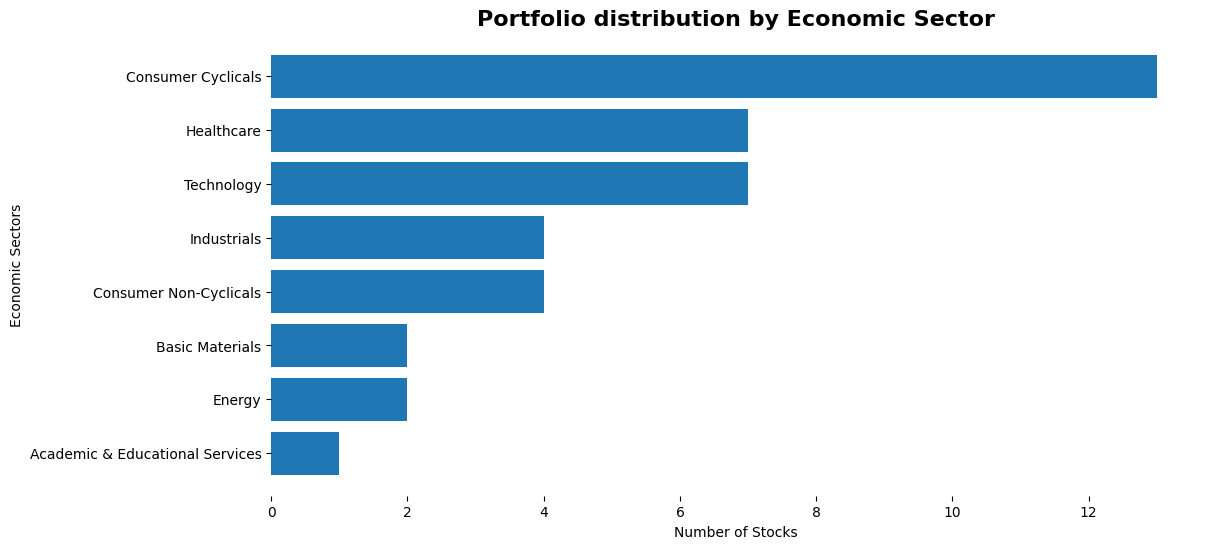

In [120]:
stocks_selected = final_qvm_df.head(40)

sector_counts = stocks_selected['TRBC Economic Sector Name'].value_counts().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(sector_counts.index, sector_counts.values)

ax.set_title("Portfolio distribution by Economic Sector", fontsize=16, fontweight='bold')
ax.set_xlabel('Number of Stocks')
ax.set_ylabel('Economic Sectors')
ax.spines[['right', 'top', 'left', 'bottom']].set_visible(False) #clean axes

plt.show()

In [128]:
today = datetime.today().date()
final_qvm_df.to_csv(f'{today}_qvm_model_per.csv')

In [123]:
#SECTOR NEUTRALIZE

#merge all the factor scores into one df
final_qvm_sector_z_df = (
    value_score_sector_z_df[['Instrument', 'TRBC Economic Sector Name', 'value_p']]
        .merge(momentum_score_sector_z_df[['Instrument', 'momentum_p']], on='Instrument', how='outer')
        .merge(quality_score_sector_z_df[['Instrument', 'quality_p']], on='Instrument', how='outer')
)

final_qvm_sector_z_df

,Instrument,TRBC Economic Sector Name,value_p,momentum_p,quality_p
0,A.N,Healthcare,61.863057,35.889799,61.427426
1,AA.N,Basic Materials,80.334395,63.440060,34.883721
2,AAL.OQ,Industrials,93.471338,16.902457,8.340016
3,AAON.OQ,Industrials,5.891720,3.499628,72.654370
4,AAP.N,Consumer Cyclicals,3.503185,52.717796,37.369687
...,...,...,...,...,...
1340,ZEUS.OQ,Basic Materials,93.550955,66.865227,63.191660
1341,ZM.OQ,Technology,89.888535,54.579300,82.678428
1342,ZS.OQ,Technology,16.560510,64.110201,NaN
1343,ZTS.N,Healthcare,72.213376,12.583768,66.158781


In [124]:
final_qvm_sector_z_df.isna().sum()

Instrument                    0
TRBC Economic Sector Name     4
value_p                      89
momentum_p                    2
quality_p                    98
dtype: int64

In [125]:
final_qvm_sector_z_df = final_qvm_sector_z_df.dropna()
final_qvm_sector_z_df.isna().sum()

Instrument                   0
TRBC Economic Sector Name    0
value_p                      0
momentum_p                   0
quality_p                    0
dtype: int64

In [126]:
# FINAL SCORE

final_qvm_sector_z_df['final_score'] = (.4 * final_qvm_sector_z_df['value_p'] +
                               .4 * final_qvm_sector_z_df['quality_p'] +
                               .2 * final_qvm_sector_z_df['momentum_p'])

#percentiles and rank
final_qvm_sector_z_df['final_score_p'] = final_qvm_sector_z_df['final_score'].rank(pct=True) * 100
final_qvm_sector_z_df['rank'] = final_qvm_sector_z_df['final_score'].rank(ascending=False)
final_qvm_sector_z_df = final_qvm_sector_z_df.sort_values(by='final_score', ascending=False)

final_qvm_sector_z_df.head(30)

C:\Users\Ramon\AppData\Local\Temp\ipykernel_17344\59136462.py:3:SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
C:\Users\Ramon\AppData\Local\Temp\ipykernel_17344\59136462.py:8:SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
C:\Users\Ramon\AppData\Local\Temp\ipykernel_17344\59136462.py:9:SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/

,Instrument,TRBC Economic Sector Name,value_p,momentum_p,quality_p,final_score,final_score_p,rank
870,NUS.N,Consumer Non-Cyclicals,94.506369,95.085629,99.278268,96.530981,100.000000,1.0
193,BWMX.N,Consumer Cyclicals,99.681529,80.938198,91.419407,92.628014,99.913570,2.0
1089,SIG.N,Consumer Cyclicals,99.363057,71.705138,94.466720,91.872939,99.827139,3.0
164,BKE.N,Consumer Cyclicals,95.222930,70.588235,98.075381,91.436971,99.740709,4.0
259,CMCL.A,Basic Materials,94.585987,96.872673,84.442662,90.985994,99.654278,5.0
498,GIC.N,Industrials,95.541401,67.758749,97.834804,90.902232,99.567848,6.0
902,OPFI.N,Technology,99.522293,57.855547,97.754611,90.481871,99.481417,7.0
758,MD.N,Healthcare,91.958599,84.586746,91.820369,90.428936,99.394987,8.0
1076,SENEA.OQ,Consumer Non-Cyclicals,95.461783,94.638868,80.834002,89.446088,99.308557,9.0
419,EVER.OQ,Technology,96.576433,76.545048,88.051323,89.160112,99.222126,10.0


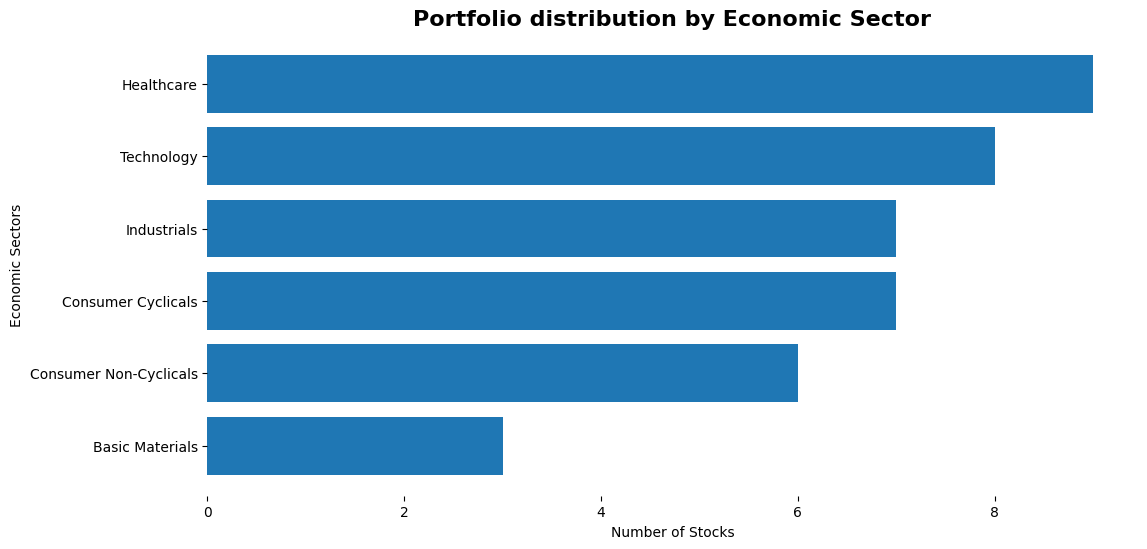

In [127]:
stocks_selected = final_qvm_sector_z_df.head(40)

sector_counts = stocks_selected['TRBC Economic Sector Name'].value_counts().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(sector_counts.index, sector_counts.values)

ax.set_title("Portfolio distribution by Economic Sector", fontsize=16, fontweight='bold')
ax.set_xlabel('Number of Stocks')
ax.set_ylabel('Economic Sectors')
ax.spines[['right', 'top', 'left', 'bottom']].set_visible(False) #clean axes

plt.show()

In [129]:
final_qvm_sector_z_df.to_csv(f'{today}_qvm_model_sector_z.csv')